### Load and Understand Data

In [ ]:
import pandas as pd


In [ ]:
df = pd.read_csv("fraud_detection_data.csv")

df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53503 entries, 0 to 53502
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Customer ID              53503 non-null  int64 
 1   Claim History            53503 non-null  int64 
 2   Previous Claims History  53503 non-null  int64 
 3   Credit Score             53503 non-null  int64 
 4   Driving Record           53503 non-null  object
dtypes: int64(4), object(1)
memory usage: 2.0+ MB


,Customer ID,Claim History,Previous Claims History,Credit Score,Driving Record
0,84966,5,3,728,DUI
1,95568,0,2,792,Clean
2,10544,4,1,719,Accident
3,77033,5,0,639,DUI
4,88160,3,3,720,Major Violations


In [ ]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [ ]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

### Feature Engineering and Data Validation

In [ ]:
df['invalid_claim_history'] = df['claim_history'] < df['previous_claims_history']

In [ ]:
print(df['invalid_claim_history'].value_counts())

invalid_claim_history
False    38915
True     14587
Name: count, dtype: int64


### Risk Categorization

In [ ]:
def risk_level(score):
  if score>= 750:
    return "Low Risk"
  elif score>= 650:
    return "Medium Risk"
  else:
    return "High Risk"
df['risk_level'] = df['credit_score'].apply(risk_level)


In [ ]:
df['high_risk_driver'] = df['driving_record'].isin(['DUI', 'Major Violations'])

### Adding Synthetic Feature (Claim Amout , Payment Amount)

In [ ]:
import numpy as np

df['claim_amount'] = (
    df['claim_history'] * 3000 +
    df['high_risk_driver'] * 10000 +
    (750 - df['credit_score']) * 50 +
    np.random.randint(0, 5000, size=len(df))
)

In [ ]:
df['payment_amount'] = df['claim_amount'] * np.random.uniform(0.85, 1.05, size=len(df))

# Make high risk more problematic
mask = (df['risk_level'] == 'High Risk') & (np.random.rand(len(df)) < 0.2)
df.loc[mask, 'payment_amount'] *= np.random.uniform(0.5, 0.8)

### Reconciliation

In [ ]:
df['difference'] = df['payment_amount'] - df['claim_amount']
df['is_mismatch'] = df['difference'].abs() > 5000

### Creating missing Data

In [ ]:
mask = (df['risk_level'] == 'High Risk') & (np.random.rand(len(df)) < 0.2)
df.loc[mask, 'payment_amount'] = np.nan

### Audit Summary

In [ ]:
audit_summary = pd.DataFrame({
    "Issue Type": ["Mismatch", "Missing Payment", "Invalid Claim History"],
    "Count": [
        df.get('is_mismatch', pd.Series([0]*len(df))).sum(),
        df.get('missing_payment', pd.Series([0]*len(df))).sum(),
        df.get('invalid_claim_history', pd.Series([0]*len(df))).sum()
    ]
})

### Export

In [ ]:
df.to_excel("finance_ready_data.xlsx", index=False)
audit_summary.to_excel("audit_report.xlsx", index=False)

## Creating Important Metrics

1.   List item
2.   List item



### Total Financial Overview

In [ ]:
total_claim = df['claim_amount'].sum()
total_paid = df['payment_amount'].sum()
outstanding = total_claim - total_paid

print(total_claim, total_paid, outstanding)

961915456 795526755.3266585 166388700.6733415


### Risk Exposure

In [ ]:

df['is_mismatch'] = df['difference'].abs() > 1000
df['missing_payment'] = df['payment_amount'].isnull()

df['is_mismatch'] = df['is_mismatch'].fillna(False)
df['missing_payment'] = df['missing_payment'].fillna(False)

risk_df = df[(df['is_mismatch']) | (df['missing_payment'])]
risk_exposure = risk_df['claim_amount'].sum()

## Core Analysis

### 1. Claim Amount by Risk Level

In [ ]:
df.groupby('risk_level')['claim_amount'].median()

,claim_amount
risk_level,
High Risk,22630.0
Low Risk,11633.0
Medium Risk,16492.0


### 2.Driving Record vs Claim Amount

In [ ]:
df.groupby('driving_record')['claim_amount'].median()

,claim_amount
driving_record,
Accident,13765.0
Clean,14065.5
DUI,23763.0
Major Violations,24016.0
Minor Violations,14149.0


### 3.Credit Score vs Claim Amount

NameError: name 'plt' is not defined

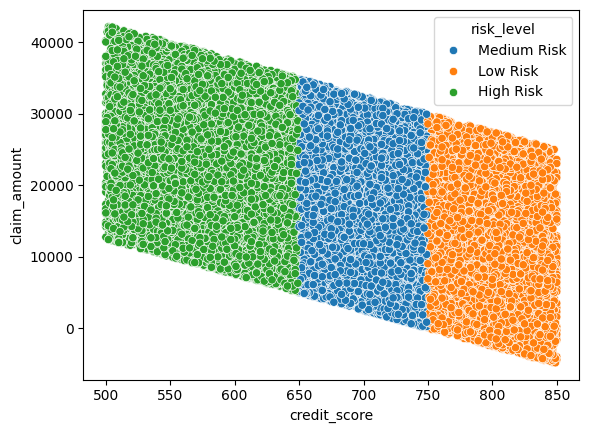

In [ ]:
import seaborn as sns
sns.scatterplot(data=df, x='credit_score', y='claim_amount', hue='risk_level')
plt.show()

### 4.Mismatch Distribution

In [ ]:
df['is_mismatch'].value_counts()

,count
is_mismatch,
False,28654
True,24848


### 5.Missing Payments Analysis

In [ ]:
df.groupby('risk_level')['missing_payment'].mean()

,missing_payment
risk_level,
High Risk,0.202441
Low Risk,0.000000
Medium Risk,0.000000
